# CIS6005 Computational Intelligence
## Notebook 02 — Dataset Understanding
**Student Health Risk Prediction | Kaggle PS S6E7**

---
### Learning Objective
By the end of this notebook you will understand:
- The shape, structure, and meaning of every column
- Data types and what they imply for preprocessing
- Missing values and duplicates at a glance
- The target variable distribution

> **Rule:** Never modify data in this notebook. Observation only.

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA     = PROJECT_ROOT / 'data' / 'raw'

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Imports complete')
print(f'📁 Data folder: {RAW_DATA}')

✅ Imports complete
📁 Data folder: d:\Student_Health_Risk_Prediction\data\raw


## 1. Load the Dataset

**Why:** We always load the raw, untouched CSVs first. We never overwrite them.

**How:** `pd.read_csv()` reads the CSV into a Pandas DataFrame — the standard tabular data structure in Python data science.

In [2]:
# ============================================================
# SECTION 1: Load Raw Data Files
# ============================================================

train_df = pd.read_csv(RAW_DATA / 'train.csv')
test_df  = pd.read_csv(RAW_DATA / 'test.csv')
sample_sub = pd.read_csv(RAW_DATA / 'sample_submission.csv')

print('=' * 60)
print('  Dataset Loading Summary')
print('=' * 60)
print(f'  Train set shape    : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'  Test set shape     : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
print(f'  Sample submission  : {sample_sub.shape[0]:,} rows × {sample_sub.shape[1]} columns')
print('=' * 60)
print('✅ All files loaded successfully')

  Dataset Loading Summary
  Train set shape    : 690,088 rows × 15 columns
  Test set shape     : 295,753 rows × 14 columns
  Sample submission  : 295,753 rows × 2 columns
✅ All files loaded successfully


## 2. First Look — Head and Tail

**Why:** `.head()` and `.tail()` give you an instant sense of the data layout, the column names, and what values look like.

In [3]:
# ============================================================
# SECTION 2: First & Last Rows
# ============================================================

print('--- FIRST 5 ROWS (train) ---')
display(train_df.head())

print('\n--- LAST 5 ROWS (train) ---')
display(train_df.tail())

--- FIRST 5 ROWS (train) ---


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male



--- LAST 5 ROWS (train) ---


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


## 3. Column Names and Data Types

**Why:** Data types tell you:
- `int64 / float64` → Numerical features → May need scaling
- `object` → Categorical features → Need encoding

**How:** `.dtypes` and `.info()` reveal this at a glance.

In [4]:
# ============================================================
# SECTION 3: Data Types and Column Information
# ============================================================

print('--- DATA TYPES ---')
print(train_df.dtypes)

print('\n--- DATASET INFO ---')
train_df.info()

--- DATA TYPES ---
id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               6822

In [5]:
# ============================================================
# SECTION 3b: Categorise Columns by Type
# ============================================================

numerical_cols   = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

# Remove id and target from feature lists
numerical_cols   = [c for c in numerical_cols if c not in ['id']]
categorical_cols = [c for c in categorical_cols if c not in ['health_condition']]

print('=' * 60)
print(f'  Numerical Features  ({len(numerical_cols)}): {numerical_cols}')
print(f'  Categorical Features({len(categorical_cols)}): {categorical_cols}')
print(f'  Target Column              : health_condition')
print('=' * 60)

  Numerical Features  (7): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
  Categorical Features(6): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
  Target Column              : health_condition


## 4. Statistical Summary

**Why:** `.describe()` shows us the min, max, mean, and percentiles for every numerical column.
This immediately reveals:
- Are there extreme values (potential outliers)?
- What is the typical range of each feature?

In [6]:
# ============================================================
# SECTION 4: Statistical Summary
# ============================================================

print('--- NUMERICAL FEATURES SUMMARY ---')
display(train_df.describe().round(2))

print('\n--- CATEGORICAL FEATURES SUMMARY ---')
display(train_df.describe(include='object'))

--- NUMERICAL FEATURES SUMMARY ---


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00,614089.00,682255.00,676190.00,637235.00,676172.00,683187.00,646611.00
mean,345043.50,6.99,75.10,22.98,2226.08,8615.95,38.75,2.19
std,199211.39,1.22,8.18,2.48,347.53,3929.40,14.74,0.52
min,0.00,3.00,50.00,16.00,1200.00,1002.00,0.00,0.50
25%,172521.75,6.16,69.40,21.32,2053.00,5389.00,29.20,1.84
50%,345043.50,6.99,75.10,22.99,2241.00,8856.00,39.40,2.17
75%,517565.25,7.81,80.70,24.66,2456.00,12114.00,49.40,2.50
max,690087.00,10.00,107.70,34.82,3580.00,14999.00,99.80,4.72



--- CATEGORICAL FEATURES SUMMARY ---


,health_condition,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
count,690088,683187,607277,631757,653467,661506,668715
unique,3,3,3,3,3,3,3
top,at-risk,veg,medium,average,moderate,yes,male
freq,592561,231432,261819,213948,221041,223730,237756


## 5. Missing Values Analysis

**Why:** Missing values (NaN) will crash most ML algorithms. We need to know:
- Which columns have missing values?
- How many are missing?
- What percentage is missing?

We handle them in Phase 4 (Data Cleaning). Here we just identify them.

In [7]:
# ============================================================
# SECTION 5: Missing Values
# ============================================================

def missing_value_report(df, name='Dataset'):
    """Generate a clean missing value report for a DataFrame."""
    missing_count = df.isnull().sum()
    missing_pct   = (df.isnull().sum() / len(df)) * 100
    
    report = pd.DataFrame({
        'Missing Count'     : missing_count,
        'Missing Percentage': missing_pct.round(2)
    })
    report = report[report['Missing Count'] > 0].sort_values(
        'Missing Percentage', ascending=False
    )
    
    print(f'\n--- {name} Missing Value Report ---')
    if report.empty:
        print('  ✅ No missing values found!')
    else:
        print(f'  ⚠️  {len(report)} column(s) have missing values:')
        display(report)
    return report

train_missing = missing_value_report(train_df, 'Training Set')
test_missing  = missing_value_report(test_df,  'Test Set')


--- Training Set Missing Value Report ---
  ⚠️  13 column(s) have missing values:


,Missing Count,Missing Percentage
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01



--- Test Set Missing Value Report ---
  ⚠️  13 column(s) have missing values:


,Missing Count,Missing Percentage
stress_level,35490,12.00
sleep_duration,32571,11.01
sleep_quality,24999,8.45
calorie_expenditure,22652,7.66
water_intake,18633,6.30
physical_activity_level,15695,5.31
smoking_alcohol,12249,4.14
gender,9160,3.10
step_count,5964,2.02
bmi,5956,2.01


## 6. Duplicate Rows

**Why:** Duplicate rows cause data leakage — the model memorises repeated samples, inflating accuracy unfairly.

In [8]:
# ============================================================
# SECTION 6: Duplicate Detection
# ============================================================

train_dups = train_df.duplicated().sum()
test_dups  = test_df.duplicated().sum()

print('=' * 60)
print('  Duplicate Row Detection')
print('=' * 60)
print(f'  Train set duplicates : {train_dups}')
print(f'  Test set duplicates  : {test_dups}')
print('=' * 60)

if train_dups > 0:
    print('  ⚠️  Duplicates found in training set. Will remove in Phase 4.')
else:
    print('  ✅ No duplicates found.')

  Duplicate Row Detection
  Train set duplicates : 0
  Test set duplicates  : 0
  ✅ No duplicates found.


## 7. Target Variable Analysis

**Why:** Understanding your target class distribution is critical. If one class dominates (class imbalance), your model will be biased toward predicting that class — giving falsely high accuracy.

The three classes are:
- **fit** — Healthy students
- **unhealthy** — Students with unhealthy habits
- **at-risk** — Students at health risk

  Target Class Distribution
  at-risk     : 592,561  (85.9%)  ██████████████████████████████████████████
  unhealthy   : 57,724  (8.4%)  ████
  fit         : 39,803  (5.8%)  ██


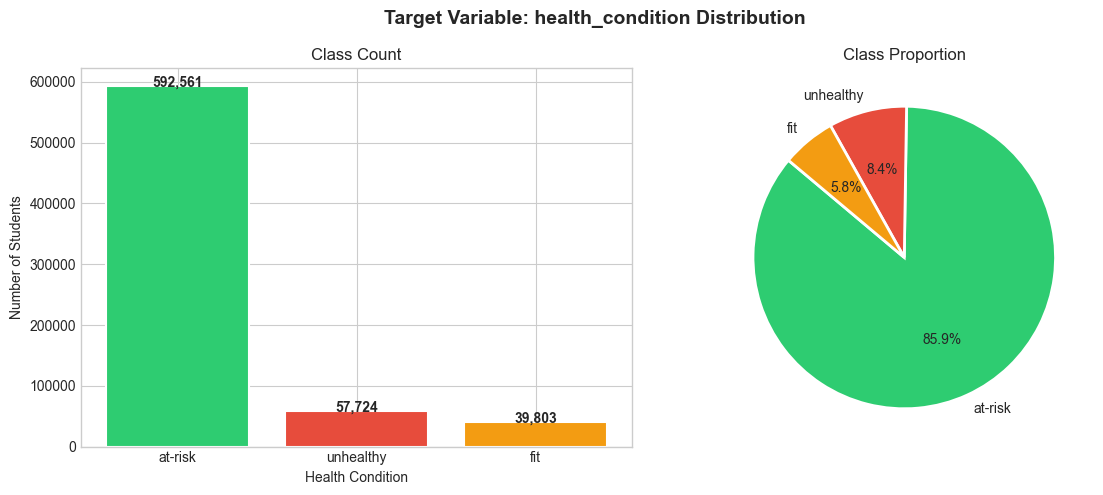


📊 Interpretation:
   Run the cell to see the actual proportions.
   If any class < 20% of total, we have class imbalance to handle.


In [9]:
# ============================================================
# SECTION 7: Target Variable Distribution
# ============================================================

target_counts = train_df['health_condition'].value_counts()
target_pct    = train_df['health_condition'].value_counts(normalize=True) * 100

print('=' * 60)
print('  Target Class Distribution')
print('=' * 60)
for cls in target_counts.index:
    bar = '█' * int(target_pct[cls] / 2)
    print(f'  {cls:<12}: {target_counts[cls]:>6,}  ({target_pct[cls]:.1f}%)  {bar}')
print('=' * 60)

# --- Visualise target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: health_condition Distribution', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#2ecc71', '#e74c3c', '#f39c12']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Count')
axes[0].set_xlabel('Health Condition')
axes[0].set_ylabel('Number of Students')
for i, (cls, cnt) in enumerate(target_counts.items()):
    axes[0].text(i, cnt + 20, f'{cnt:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Interpretation:')
print('   Run the cell to see the actual proportions.')
print('   If any class < 20% of total, we have class imbalance to handle.')

## 8. Unique Values in Categorical Columns

**Why:** Knowing the unique values helps us plan the encoding strategy in Phase 6.

In [10]:
# ============================================================
# SECTION 8: Categorical Column Unique Values
# ============================================================

cat_feature_cols = train_df.select_dtypes(include='object').columns.tolist()

print('=' * 60)
print('  Categorical Column Unique Values')
print('=' * 60)
for col in cat_feature_cols:
    unique_vals = train_df[col].unique().tolist()
    print(f'  {col:<30}: {unique_vals}')
print('=' * 60)

  Categorical Column Unique Values
  health_condition              : ['unhealthy', 'at-risk', 'fit']
  diet_type                     : ['veg', 'non-veg', 'balanced', nan]
  stress_level                  : ['high', 'low', nan, 'medium']
  sleep_quality                 : ['average', 'poor', nan, 'good']
  physical_activity_level       : ['sedentary', 'moderate', 'active', nan]
  smoking_alcohol               : ['yes', 'occasional', nan, 'no']
  gender                        : ['female', 'other', 'male', nan]


## 9. Dataset Understanding Summary

Run this cell after all cells above to produce a final summary card.

In [11]:
# ============================================================
# SECTION 9: Phase Summary
# ============================================================

print('=' * 60)
print('  PHASE 2 COMPLETE — Dataset Understanding Summary')
print('=' * 60)
print(f'  Train Rows          : {train_df.shape[0]:,}')
print(f'  Train Columns       : {train_df.shape[1]}')
print(f'  Test Rows           : {test_df.shape[0]:,}')
print(f'  Numerical Features  : {len(numerical_cols)}')
print(f'  Categorical Features: {len(categorical_cols)}')
print(f'  Target Classes      : {list(train_df["health_condition"].unique())}')
print(f'  Missing Values      : {train_df.isnull().sum().sum()} cells')
print(f'  Duplicate Rows      : {train_df.duplicated().sum()}')
print('=' * 60)
print('  ✅ Ready for Phase 3: Exploratory Data Analysis')
print('=' * 60)

  PHASE 2 COMPLETE — Dataset Understanding Summary
  Train Rows          : 690,088
  Train Columns       : 15
  Test Rows           : 295,753
  Numerical Features  : 7
  Categorical Features: 6
  Target Classes      : ['unhealthy', 'at-risk', 'fit']


  Missing Values      : 449496 cells


  Duplicate Rows      : 0
  ✅ Ready for Phase 3: Exploratory Data Analysis
